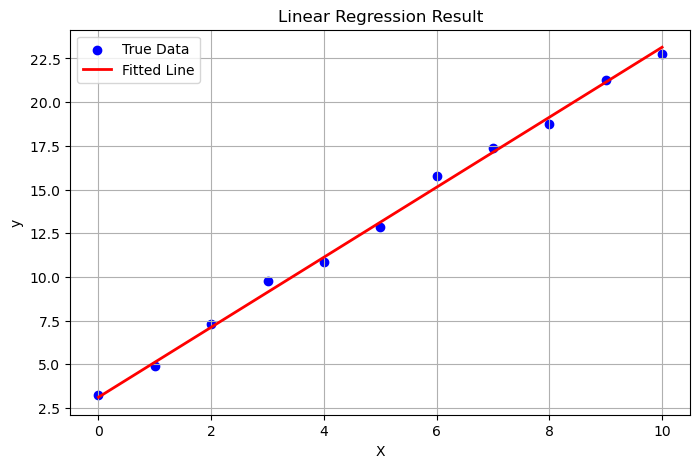

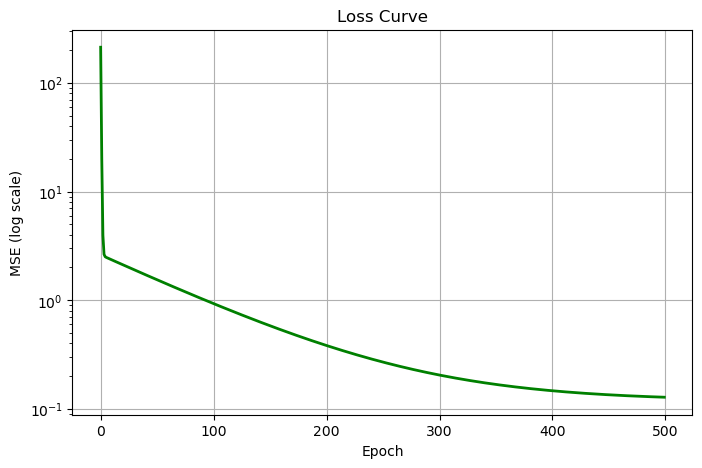

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) #设置随机种子,保持每次生成随机数相同
X=np.linspace(0,10,11).reshape(-1,1) #任意行1列 0 1 2-10 11个
#linspace 均值分配
y=2*X+3+np.random.randn(11,1)*0.5#真实值为w=2,b=3。模型是为了学习w=2,b=3
#加入均值为0,标准差为0.5的高斯噪声,模拟真实数据的误差。后面random是噪声
w=np.array([[0.0]])
b=np.array([[0.0]]) #(1,1)

lr=0.01 #学习率:控制每次更新步长
epochs=500 #迭代次数
losses=[] #记录每一轮损失值

for i in range(epochs):
    y_pred=X@w+b
    #使用均方误差MSE计算损失
    loss=np.mean((y_pred-y)**2)
    losses.append(float(loss))
    #使用均方误差MSE,因为MSE是凸函数,有唯一的全局最小值;
    #其导数形式为线性,梯度计算方便；对异常值敏感,能推动模型快速修正
    
    #反向传播:计算梯度 dl/dw，dL/db 求导
    grad_w=(2/len(X))*(X.T@(y_pred-y))
    grad_b=(2/len(X))*np.sum(y_pred-y)
    #更新参数 反向更新参数
    w=w-lr*grad_w
    b=b-lr*grad_b
    #w和b从0开始向2x+3接近
# 绘制拟合结果
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='True Data')  # 画出真实数据点（蓝色散点）
plt.plot(X, X @ w + b, color='red', linewidth=2, label='Fitted Line')  # 画出模型拟合的直线（红色）
plt.title('Linear Regression Result')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()  # 显示图例
plt.grid(True)
plt.show()

# 绘制损失曲线
plt.figure(figsize=(8, 5))          # 设置画布大小
plt.plot(range(len(losses)), losses, 'g-', linewidth=2)  # 画出损失曲线
plt.title('Loss Curve')             # 损失曲线
plt.xlabel('Epoch')                 # X轴标签；迭代次数
plt.ylabel('MSE (log scale)')       # Y轴标签；均方误差
plt.yscale('log')                   # 关键：Y轴用对数刻度，能清晰看到从高到低的完整下降过程
plt.grid(True)                      # 显示网格线，方便看数值
plt.show()
# 损失值如果从150-3相差两个数量级，用直线会变成垂直线。使用log后10^2,10^1相差只有1个单元格

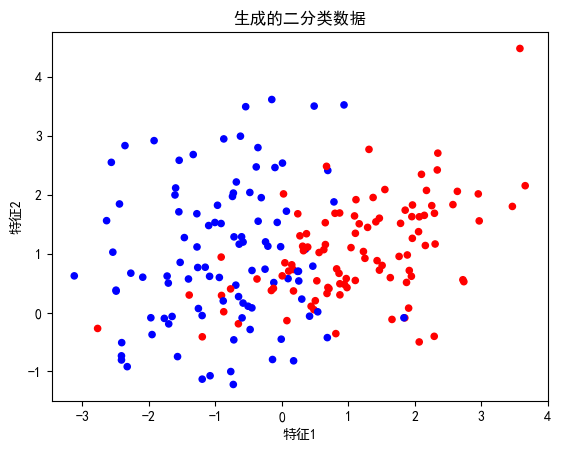

epoch0,loss=0.9355
epoch100,loss=0.3802
epoch200,loss=0.3690
epoch300,loss=0.3669
epoch400,loss=0.3663
epoch500,loss=0.3661
epoch600,loss=0.3660
epoch700,loss=0.3659
epoch800,loss=0.3659
epoch900,loss=0.3659

训练完成,theta=[ 0.21287553  1.94367116 -0.45321958]
sklearn 截距: 0.2194, 系数: [ 1.94724175 -0.4579085 ]


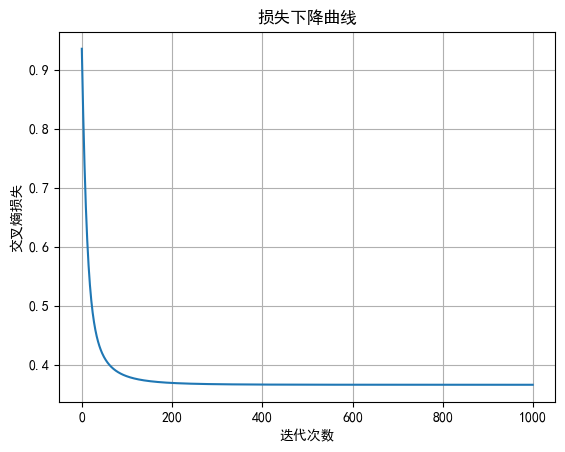

In [7]:
#交叉熵损失,手写逻辑回归
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
plt.rcParams['font.sans-serif'] = ['SimHei']        # 使用黑体
plt.rcParams['axes.unicode_minus'] = False          # 解决负号显示异常
#生成2分类数据,=
np.random.seed(42)
X,y=make_classification(n_samples=200,n_features=2,n_redundant=0,
                       n_clusters_per_class=1,random_state=42)
#n_samples 样本个数,样本特征个数2,冗余特征0，每个类簇的个数n_clusters_per_class,随机种子指定42

plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr',s=20) 
#viridis黑黄,coolwarm 红蓝 bwr 红蓝对比度更大
#[[1,2],[3,4],[5,6]] 生成如此的二维数组,如果feature=3,一行三个
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('生成的二分类数据')
plt.show()
#初始化参数

X_bias=np.c_[np.ones((X.shape[0],1)),X] #形状(200,3) 左边拼接200行1列的1

theta=np.random.randn(3,1) #初始化参数(3,1) 系数
lr=0.1 #学习率为0.1
epochs=1000 
m=len(X_bias) #200
#用于记录损失
loss_history=[]
def sigmoid(z):
    return 1/(1+np.exp(-z))
y = y.reshape(-1, 1) #变成(200,1)
#梯度下降
for epoch in range(epochs):
    z=X_bias @ theta #(200,1) 线性组合
    #预测概率
    y_pred=sigmoid(z)
    #交叉熵损失 L(y,p)=−[ylogp+(1−y)log(1−p)] 一个样本的交叉熵损失。
    loss=-np.mean(y*np.log(y_pred+1e-8)+(1-y)*np.log(1-y_pred+1e-8))
    loss_history.append(loss)
    #梯度
    dz=y_pred-y.reshape(-1,1)#(200,1)
    grad=(1/m)*X_bias.T.dot(dz) #(3,1)
    theta=theta-lr*grad
    if epoch %100==0 :
        print(f"epoch{epoch},loss={loss:.4f}")
print(f"\n训练完成,theta={theta.flatten()}")
#sklearn方式
#lr_sk=LogisticRegression()
lr_sk = LogisticRegression(penalty=None, solver='lbfgs')  # 无正则化
lr_sk.fit(X,y.ravel())#ravel压平
print(f"sklearn 截距: {lr_sk.intercept_[0]:.4f}, 系数: {lr_sk.coef_[0]}")

# 损失曲线
plt.plot(loss_history)
plt.xlabel('迭代次数')
plt.ylabel('交叉熵损失')
plt.title('损失下降曲线')
plt.grid(True)
plt.show()
#逻辑回归的决策边界 ≈ 线性回归的拟合直线，都是训练过程中逐渐趋近的一个线性方程。 区别在于前者用于分类，后者用于回归。